<a href="https://colab.research.google.com/github/muadzm3/Praktikum1-AI/blob/main/Klasifikasi_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv('student_data.csv')

print(df.head())

  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]


In [4]:
X = df[['studytime', 'absences', 'freetime']]
y = (df['G3'] >= 10).astype(int)

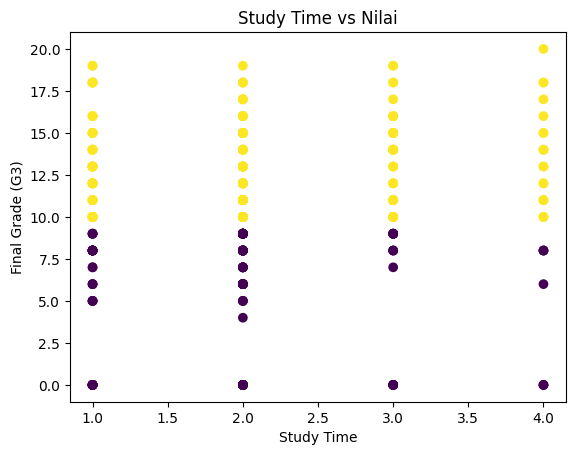

In [5]:
plt.scatter(df['studytime'], df['G3'], c=y)
plt.xlabel("Study Time")
plt.ylabel("Final Grade (G3)")
plt.title("Study Time vs Nilai")
plt.show()

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [8]:
print("Akurasi:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Akurasi: 0.5822784810126582

Confusion Matrix:
 [[ 7 20]
 [13 39]]

Classification Report:
               precision    recall  f1-score   support

           0       0.35      0.26      0.30        27
           1       0.66      0.75      0.70        52

    accuracy                           0.58        79
   macro avg       0.51      0.50      0.50        79
weighted avg       0.55      0.58      0.56        79



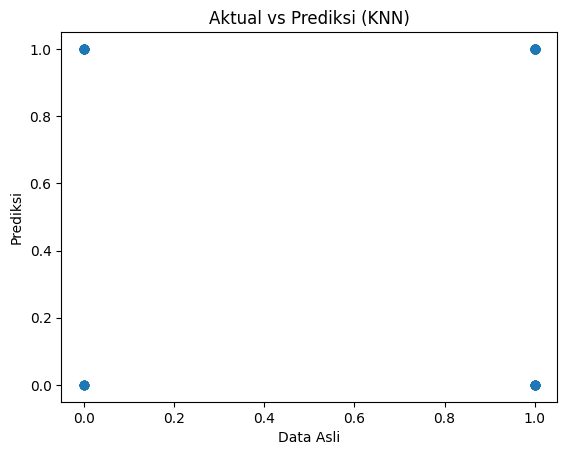

In [10]:
plt.scatter(y_test, y_pred)
plt.xlabel("Data Asli")
plt.ylabel("Prediksi")
plt.title("Aktual vs Prediksi (KNN)")
plt.show()